# CSV 파일 합치기

테이블 관계:
```
Membership --(USER_KEY)--> User_Mapping --(USER_NUM)--> View_History --(MOVIE_NUM)--> Movie_Master
```

## Step 0. 데이터 불러오기

In [31]:
import pandas as pd

path = r'260430_membership_v1(이상치, 이름변경)'

membership    = pd.read_csv(f'{path}/Membership_v1.csv')
movie_master  = pd.read_csv(f'{path}/Movie_Master_v1.csv')
user_mapping  = pd.read_csv(f'{path}/User_Mapping_v1.csv')
view_history  = pd.read_csv(f'{path}/View_History_v1.csv')

print('membership   :', membership.shape)
print('movie_master :', movie_master.shape)
print('user_mapping :', user_mapping.shape)
print('view_history :', view_history.shape)

membership   : (17876, 15)
movie_master : (14018, 3)
user_mapping : (19877, 2)
view_history : (106205, 5)


## Step 1. Membership + User_Mapping 합치기
- 공통 키: `USER_KEY`
- `how='left'` → membership 전체 유지, 매핑 안 된 행은 USER_NUM이 NaN으로 채워짐

In [32]:
df1 = pd.merge(membership, user_mapping, on='USER_KEY', how='left')

print('membership 원본:', membership.shape[0], '행')
print('merge 후       :', df1.shape[0], '행  ← 행 수 동일해야 정상')
print()
print('USER_NUM 매핑 안 된 행:', df1['USER_NUM'].isnull().sum())
print('USER_NUM 매핑 된 행  :', df1['USER_NUM'].notnull().sum())
df1.head(3)

membership 원본: 17876 행
merge 후       : 17980 행  ← 행 수 동일해야 정상

USER_NUM 매핑 안 된 행: 0
USER_NUM 매핑 된 행  : 17980


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,USER_NUM
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,2342
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,1,1,0,pc,1,F,25,2021-03-09,14,2021-04-09,17323
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.0,132,1,1,0,0,android,1,F,55,2021-03-09,22,2021-04-09,14848


In [33]:
# user_mapping에 중복 USER_KEY 있는지 확인
dup = user_mapping[user_mapping.duplicated('USER_KEY', keep=False)]
print('user_mapping 전체 행:', len(user_mapping))
print('USER_KEY 고유값 수  :', user_mapping['USER_KEY'].nunique())
print('중복된 USER_KEY 행  :', len(dup))
dup.sort_values('USER_KEY').head(10)

user_mapping 전체 행: 19877
USER_KEY 고유값 수  : 19828
중복된 USER_KEY 행  : 97


,USER_KEY,USER_NUM
16255,0258fd467c5765400d487d203f7c77afb597120daa9b1e...,16255
3363,0258fd467c5765400d487d203f7c77afb597120daa9b1e...,3363
1503,03207f956c0a2d363285286b1a9ede62e03373a9242253...,1503
5706,03207f956c0a2d363285286b1a9ede62e03373a9242253...,5706
13820,06413c96660e23ddd8e6cc93b3e03e299201a9a1aa05ba...,13820
17661,06413c96660e23ddd8e6cc93b3e03e299201a9a1aa05ba...,17661
10426,072c0b5986c11d3c3e14fcd4f213a2cba2e973e41e635c...,10426
15041,072c0b5986c11d3c3e14fcd4f213a2cba2e973e41e635c...,15041
1781,07e8934c2a06f8b6e27296413d04e783282f9446ea0c8c...,1781
3216,07e8934c2a06f8b6e27296413d04e783282f9446ea0c8c...,3216


In [34]:
# user_mapping에서 중복 USER_KEY별 등장 횟수
dup_counts = user_mapping.groupby('USER_KEY').size()
dup_keys = dup_counts[dup_counts > 1]
print('중복 USER_KEY 종류:', len(dup_keys))
print('횟수별 분포:')
print(dup_keys.value_counts().sort_index())

# 이 중복 KEY들이 membership에 몇 개 있는지
dup_in_membership = membership['USER_KEY'].isin(dup_keys.index).sum()
print('\nmembership에서 중복 KEY 해당 행:', dup_in_membership)

# 이론상 늘어나는 행 수 계산
extra = 0
for key, cnt in dup_keys.items():
    mem_cnt = (membership['USER_KEY'] == key).sum()
    extra += mem_cnt * (cnt - 1)
print('이론상 증가 행 수:', extra)
print('실제 증가 행 수  :', 17980 - 17876)

중복 USER_KEY 종류: 48
횟수별 분포:
2    47
3     1
Name: count, dtype: int64

membership에서 중복 KEY 해당 행: 97
이론상 증가 행 수: 104
실제 증가 행 수  : 104


## Step 2. + View_History 합치기
- 공통 키: `USER_NUM`
- 목적: 각 유저의 시청 기록 연결

In [35]:
df2 = pd.merge(df1, view_history, on='USER_NUM', how='left')

print('결과 shape:', df2.shape)
df2.head(3)

결과 shape: (110065, 20)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,USER_NUM,MOVIE_NUM,watch_time(min),watch_day,watch_seq
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,2342,13273.0,48.0,20210314.0,1.0
1,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,2342,13273.0,55.0,20210315.0,1.0
2,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,2342,11983.0,88.0,20210320.0,1.0


## Step 3. + Movie_Master 합치기
- 공통 키: `MOVIE_NUM`
- 목적: 시청한 영화 정보(제목, 출시월) 연결

In [36]:
df_final = pd.merge(df2, movie_master, on='MOVIE_NUM', how='left')

print('최종 shape:', df_final.shape)
print('컬럼 목록:', df_final.columns.tolist())
df_final.head(3)

최종 shape: (110065, 22)
컬럼 목록: ['USER_KEY', 'product_code', 'price', 'billing_method', 'max_screen', 'is_promotion', 'is_churn_prevented', 'is_repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_date', 'reg_hour', 'end_date', 'USER_NUM', 'MOVIE_NUM', 'watch_time(min)', 'watch_day', 'watch_seq', 'movie_title', 'ott_release_month']


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,...,reg_date,reg_hour,end_date,USER_NUM,MOVIE_NUM,watch_time(min),watch_day,watch_seq,movie_title,ott_release_month
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,...,2021-03-14,20,2021-04-14,2342,13273.0,48.0,20210314.0,1.0,버티칼리미트(2000),201707.0
1,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,...,2021-03-14,20,2021-04-14,2342,13273.0,55.0,20210315.0,1.0,버티칼리미트(2000),201707.0
2,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,...,2021-03-14,20,2021-04-14,2342,11983.0,88.0,20210320.0,1.0,신의한수:귀수편,201912.0


## Step 4. 결측치 확인

In [37]:
df_final.isnull().sum()

USER_KEY                 0
product_code             0
price                    0
billing_method           0
max_screen               0
is_promotion             0
is_churn_prevented       0
is_repurchase            0
payment_device           0
is_user_verified         0
gender                   0
age                      0
reg_date                 0
reg_hour                 0
end_date                 0
USER_NUM                 0
MOVIE_NUM             3013
watch_time(min)       3013
watch_day             3013
watch_seq             3013
movie_title           3013
ott_release_month     3013
dtype: int64

In [38]:
df_final.to_csv('merged_0430.csv', index=False, encoding='utf-8-sig')
print('저장 완료!')

저장 완료!


# 데이터 전처리

In [39]:
df = pd.read_csv('260430_membership_v1(이상치, 이름변경)/Membership_v1.csv')
# max_screen 값 확인
print(df['max_screen'].value_counts().sort_index())

max_screen
1    11229
2     3757
4     2890
Name: count, dtype: int64


In [40]:
df = df.drop(columns=['is_basic', 'is_standard', 'is_premium', 'screen_tier'], errors='ignore')

screen_map = {1: 'is_basic', 2: 'is_standard', 4: 'is_premium'}
df['screen_tier'] = df['max_screen'].map(screen_map)

dummies = pd.get_dummies(df['screen_tier'], prefix='').rename(columns=lambda x: x.strip('_')).astype(int)
df = pd.concat([df, dummies], axis=1)
df = df.drop(columns=['screen_tier'])

print(df[['max_screen', 'is_basic', 'is_standard', 'is_premium']].drop_duplicates().sort_values('max_screen'))
print('\nshape:', df.shape)

df = df.drop(columns=['max_screen'], errors='ignore')
print('최종 shape:', df.shape)

   max_screen  is_basic  is_standard  is_premium
1           1         1            0           0
4           2         0            1           0
0           4         0            0           1

shape: (17876, 18)
최종 shape: (17876, 17)


In [41]:
df.to_csv('membership_data.csv', index=False, encoding='utf-8-sig')
print('저장 완료!')

저장 완료!


In [42]:
print(df['payment_device'].value_counts())

payment_device
android    8381
pc         3438
ios        2996
mobile     2746
smarttv     253
ott          62
Name: count, dtype: int64


In [43]:
# df = df.drop(columns=[c for c in df.columns if c.startswith('device_')], errors='ignore')

# dummies = pd.get_dummies(df['payment_device'], prefix='device').astype(int)
# df = pd.concat([df, dummies], axis=1)
# df = df.drop(columns=['payment_device'])

# print(df[[c for c in df.columns if c.startswith('device_')]].drop_duplicates())
# print('\nshape:', df.shape)

In [44]:
# df_final에서 시청이력 있는 USER_KEY 추출
users_with_history = set(df_final[df_final['MOVIE_NUM'].notna()]['USER_KEY'])
df['has_view_history'] = df['USER_KEY'].isin(users_with_history).astype(int)

print(df['has_view_history'].value_counts())
print('시청이력 있음(1):', df['has_view_history'].sum(), '명')
print('시청이력 없음(0):', (df['has_view_history']==0).sum(), '명')

df.to_csv('membership_data.csv', index=False, encoding='utf-8-sig')
print('\nmembership_data.csv 저장 완료!')

has_view_history
1    14873
0     3003
Name: count, dtype: int64
시청이력 있음(1): 14873 명
시청이력 없음(0): 3003 명

membership_data.csv 저장 완료!


In [45]:
df_m = pd.read_csv('membership_data.csv')

print('전체 행 수:', len(df_m))
print()
print('USER_KEY 고유값 수:', df_m['USER_KEY'].nunique(), '→ 중복:', len(df_m) - df_m['USER_KEY'].nunique())
# print('USER_NUM 고유값 수:', df_m['USER_NUM'].nunique(), '→ 중복:', len(df_m) - df_m['USER_NUM'].nunique())

전체 행 수: 17876

USER_KEY 고유값 수: 17578 → 중복: 298


In [46]:
# USER_KEY 당 몇 개의 행이 있는지 분포 확인
key_counts = df_m['USER_KEY'].value_counts()
print('USER_KEY 당 행 수 분포:')
print(key_counts.value_counts().sort_index())
print()
# 중복된 USER_KEY 예시
dup_key = key_counts[key_counts > 1].index[0]
print('예시 (중복 USER_KEY 1개):')
df_m[df_m['USER_KEY'] == dup_key][['USER_KEY', 'product_code', 'reg_date', 'end_date']]

USER_KEY 당 행 수 분포:
count
1    17312
2      248
3       12
4        2
5        2
7        2
Name: count, dtype: int64

예시 (중복 USER_KEY 1개):


,USER_KEY,product_code,reg_date,end_date
53,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1488,2021-03-12,2021-04-12
850,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1487,2021-03-09,2021-03-12
2196,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1488,2021-03-08,2021-03-09
8345,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1488,2021-03-05,2021-03-07
10553,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1488,2021-03-02,2021-03-04
14137,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1487,2021-03-07,2021-03-08
15875,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1487,2021-03-04,2021-03-05


In [47]:
print(df_m['price'].value_counts().sort_index())

price
9.89           6
9.99        2104
10.99         37
13.19          2
13.49        609
14.29         18
16.49        213
17.59          2
20.49          1
21.99          1
24.19          1
27.49          1
29.69          1
100.00      9061
3350.00        1
3950.00      129
4900.00        1
5450.00       41
5900.00        5
6210.00        4
6700.00       76
6900.00       23
6950.00       50
7900.00     3299
10900.00    1570
11550.00       1
11800.00       2
13750.00      30
13900.00     587
Name: count, dtype: int64


In [48]:
# 가격 유형 변수 추가 (prom: 0=정가, 1=반값, 2=100원딜)
df_m['prom'] = 0
df_m.loc[df_m['price'].between(3350, 6950), 'prom'] = 1
df_m.loc[df_m['price'] == 100, 'prom'] = 2

print(df_m['prom'].value_counts().sort_index())
print('정가(0)  :', (df_m['prom'] == 0).sum(), '명')
print('반값(1)  :', (df_m['prom'] == 1).sum(), '명')
print('100원(2) :', (df_m['prom'] == 2).sum(), '명')

df_m.to_csv('membership_data.csv', index=False, encoding='utf-8-sig')
print('\nmembership_data.csv 저장 완료!')

prom
0    8485
1     330
2    9061
Name: count, dtype: int64
정가(0)  : 8485 명
반값(1)  : 330 명
100원(2) : 9061 명

membership_data.csv 저장 완료!


# EDA - membership_data.csv

In [49]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df_m = pd.read_csv('membership_data.csv')
print(df_m.shape)
df_m.head(3)

(17876, 19)


,USER_KEY,product_code,price,billing_method,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,is_basic,is_premium,is_standard,has_view_history,prom
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,0,1,0,1,2
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,1,0,pc,1,F,25,2021-03-09,14,2021-04-09,1,0,0,1,2
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.0,132,1,0,0,android,1,F,55,2021-03-09,22,2021-04-09,1,0,0,0,2


## 1. 전체 변수 분포

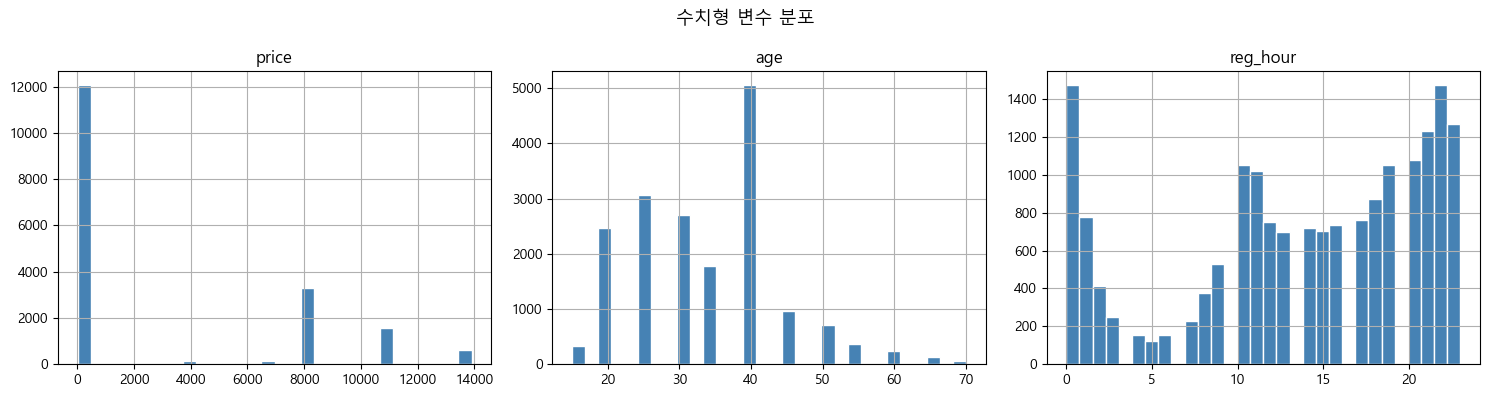

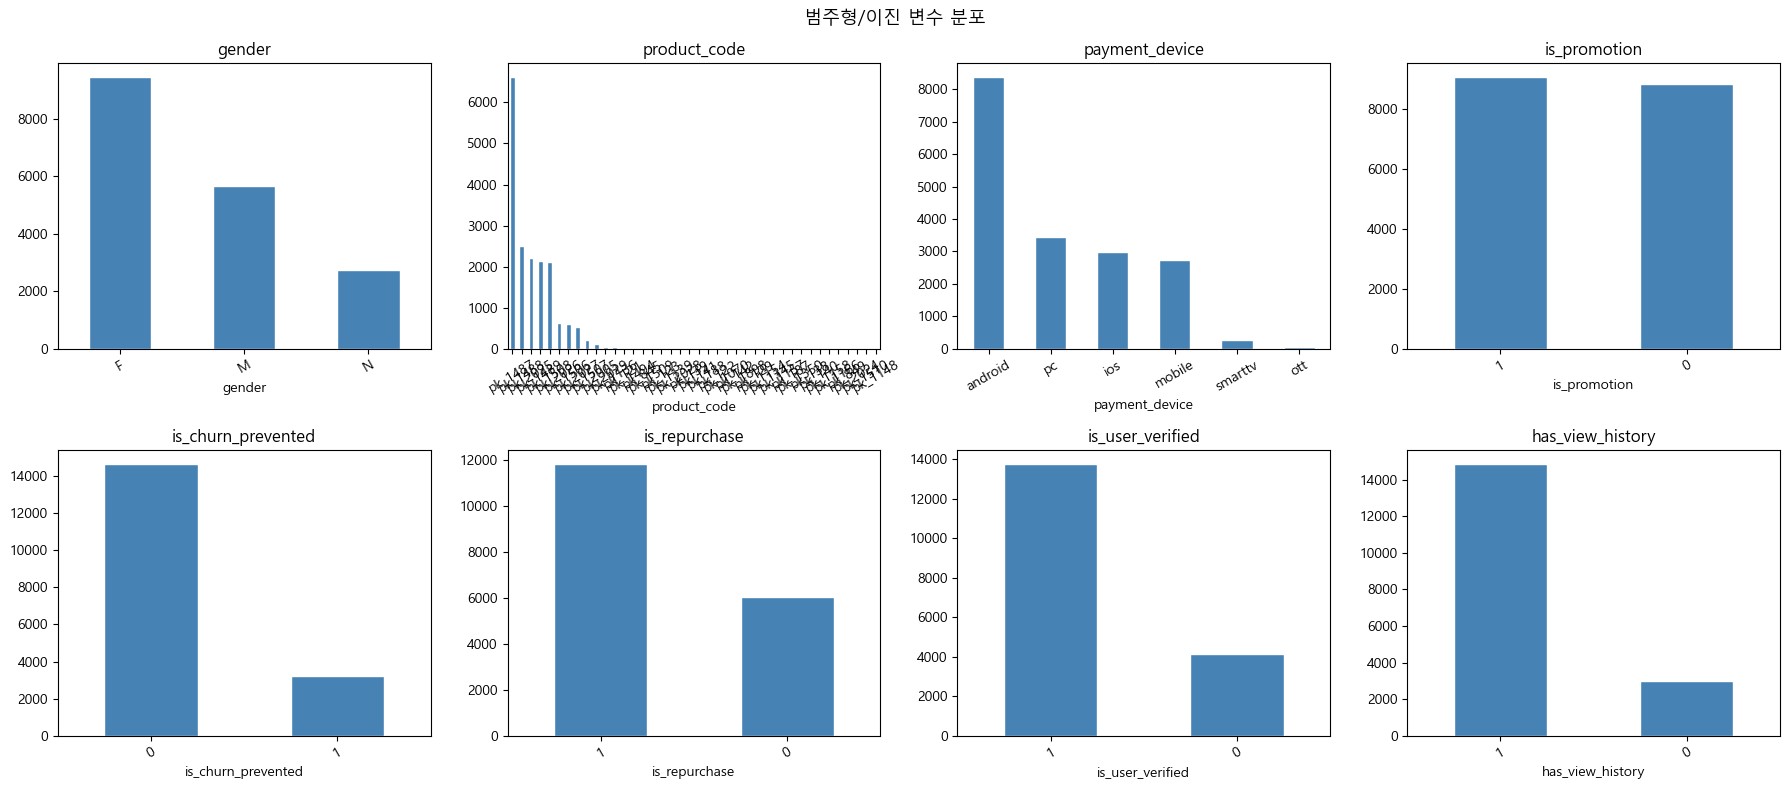

In [50]:
# 수치형 변수 분포
num_cols = ['price', 'age', 'reg_hour']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df_m[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('수치형 변수 분포', fontsize=13)
plt.tight_layout()
plt.show()

# 범주형/이진 변수 분포
cat_cols = ['gender', 'product_code', 'payment_device', 'is_promotion',
            'is_churn_prevented', 'is_repurchase', 'is_user_verified', 'has_view_history']
cat_cols = [c for c in cat_cols if c in df_m.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    df_m[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)
plt.suptitle('범주형/이진 변수 분포', fontsize=13)
plt.tight_layout()
plt.show()

## 2. is_repurchase 기준

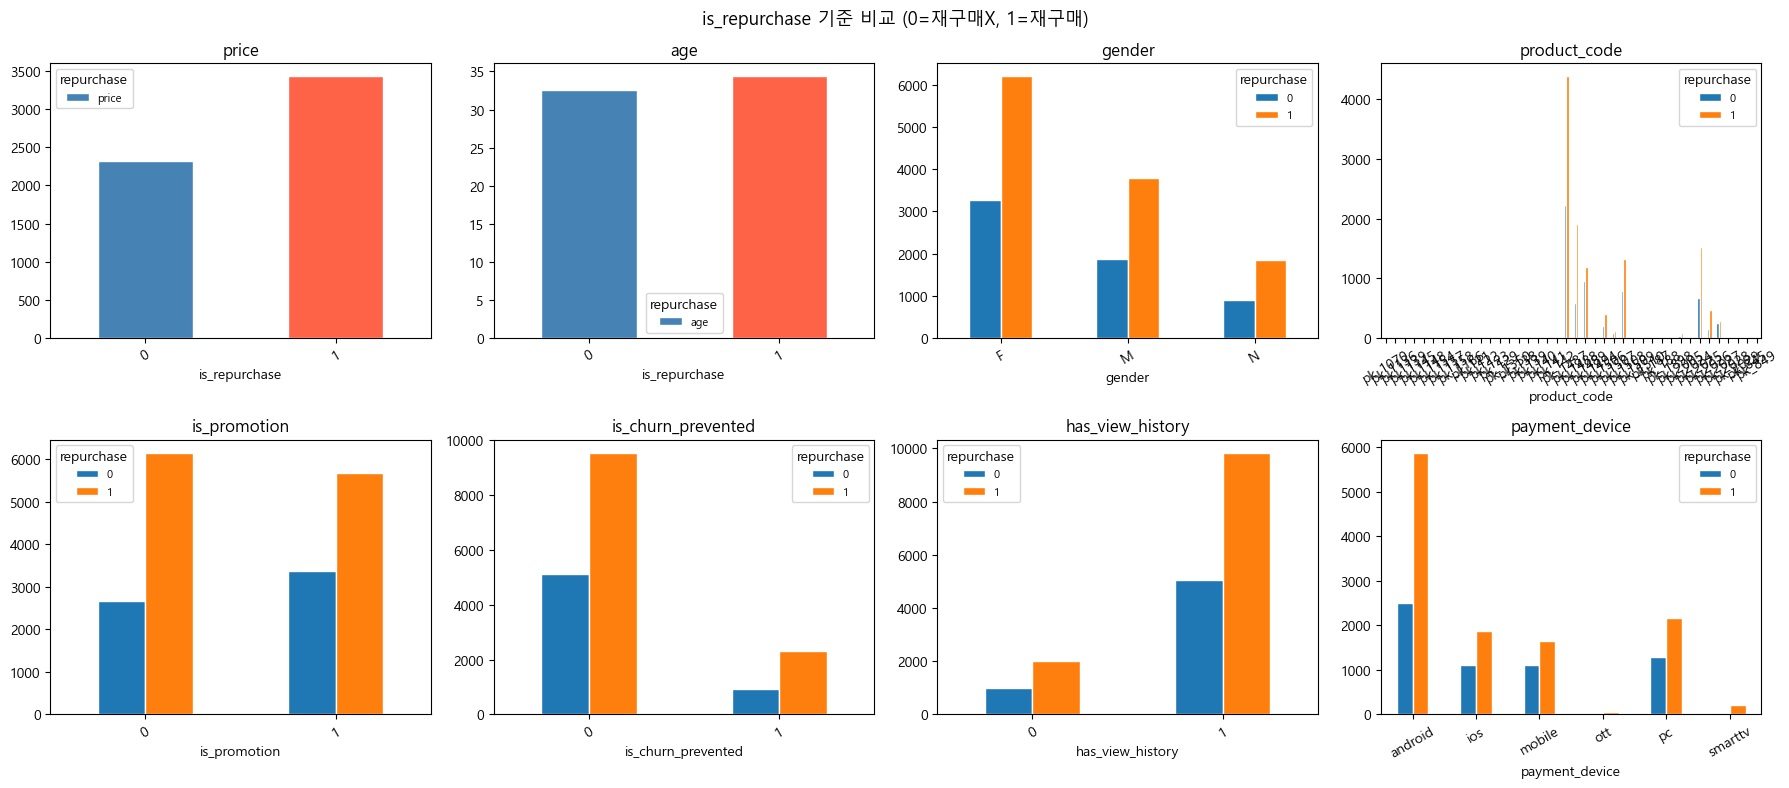

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

compare_cols = ['price', 'age', 'gender', 'product_code',
                'is_promotion', 'is_churn_prevented', 'has_view_history', 'payment_device']
compare_cols = [c for c in compare_cols if c in df_m.columns]

for ax, col in zip(axes, compare_cols):
    if df_m[col].dtype == 'object' or df_m[col].nunique() <= 10:
        df_m.groupby([col, 'is_repurchase']).size().unstack().plot(kind='bar', ax=ax, edgecolor='white')
    else:
        df_m.groupby('is_repurchase')[col].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='repurchase', fontsize=8)

for ax in axes[len(compare_cols):]:
    ax.set_visible(False)
plt.suptitle('is_repurchase 기준 비교 (0=재구매X, 1=재구매)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. is_promotion 기준

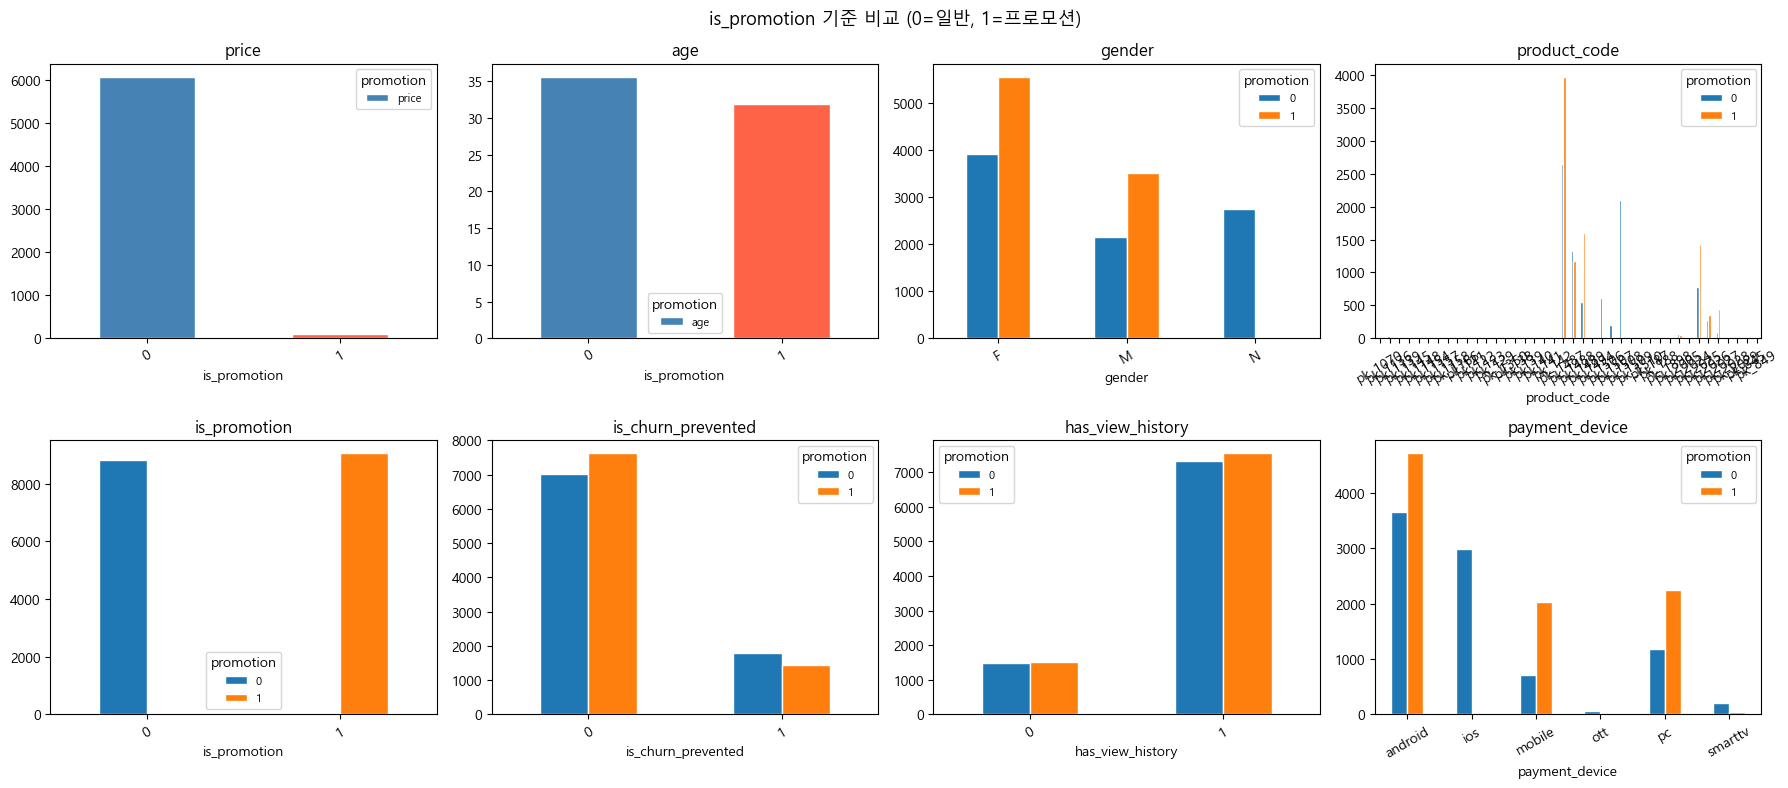

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, compare_cols):
    if df_m[col].dtype == 'object' or df_m[col].nunique() <= 10:
        df_m.groupby([col, 'is_promotion']).size().unstack().plot(kind='bar', ax=ax, edgecolor='white')
    else:
        df_m.groupby('is_promotion')[col].mean().plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='promotion', fontsize=8)

for ax in axes[len(compare_cols):]:
    ax.set_visible(False)
plt.suptitle('is_promotion 기준 비교 (0=일반, 1=프로모션)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 연령대별

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2545939357.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_m.groupby('age_group')[col].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2545939357.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_m.groupby(['age_group', col]).size().unstack().plot(kind='bar', ax=ax, edgecolor='white')
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2545939357.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass obse

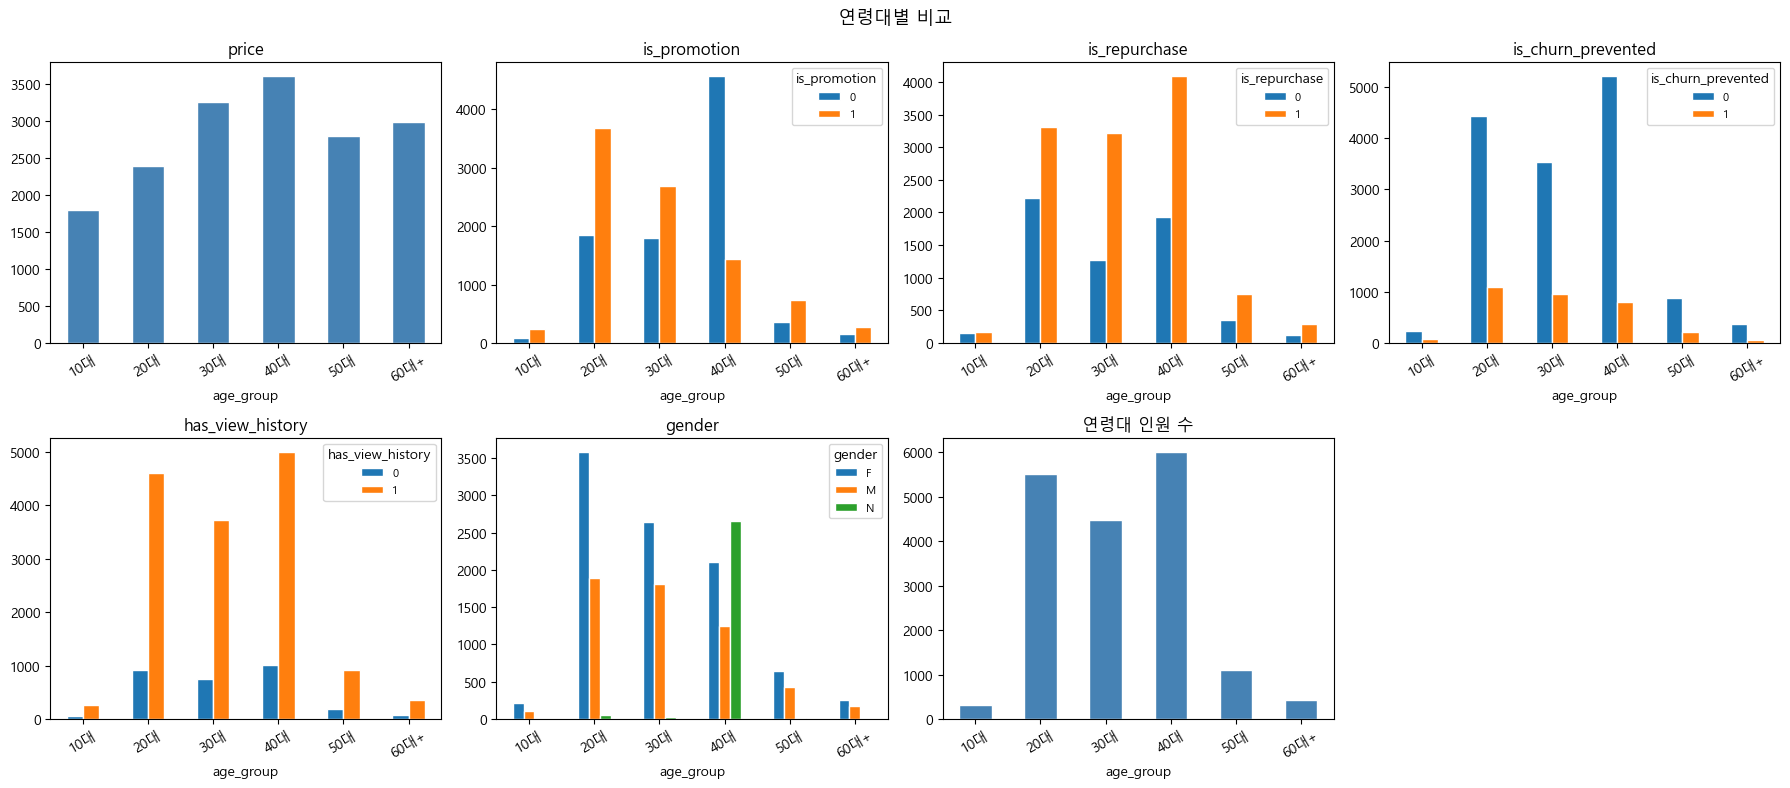

In [53]:
df_m['age_group'] = pd.cut(df_m['age'], bins=[0,19,29,39,49,59,100],
                           labels=['10대','20대','30대','40대','50대','60대+'])

age_cols = ['price', 'is_promotion', 'is_repurchase', 'is_churn_prevented',
            'has_view_history', 'gender']
age_cols = [c for c in age_cols if c in df_m.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, age_cols):
    if df_m[col].dtype == 'object' or df_m[col].nunique() <= 5:
        df_m.groupby(['age_group', col]).size().unstack().plot(kind='bar', ax=ax, edgecolor='white')
        ax.legend(title=col, fontsize=8)
    else:
        df_m.groupby('age_group')[col].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

# 연령대 인원 수
df_m['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[len(age_cols)],
                                                    color='steelblue', edgecolor='white')
axes[len(age_cols)].set_title('연령대 인원 수')
axes[len(age_cols)].tick_params(axis='x', rotation=30)

for ax in axes[len(age_cols)+1:]:
    ax.set_visible(False)
plt.suptitle('연령대별 비교', fontsize=13)
plt.tight_layout()
plt.show()

## 5. 수치형 변수 상관관계

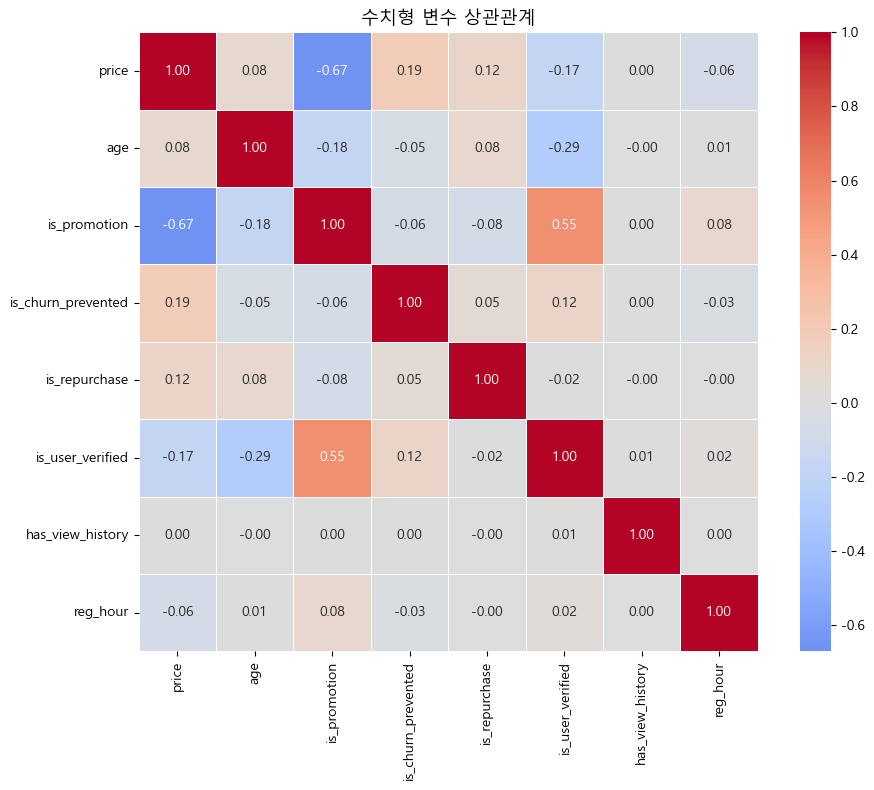

In [54]:
import seaborn as sns

corr_cols = ['price', 'age', 'is_promotion', 'is_churn_prevented',
             'is_repurchase', 'is_user_verified', 'has_view_history', 'reg_hour']
corr_cols = [c for c in corr_cols if c in df_m.columns]

corr = df_m[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('수치형 변수 상관관계', fontsize=13)
plt.tight_layout()
plt.show()

## 6. 재구매율 세그먼트 분석 (비율 기준)

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\234521832.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_m.groupby('age_group')['is_repurchase'].mean().mul(100).plot(


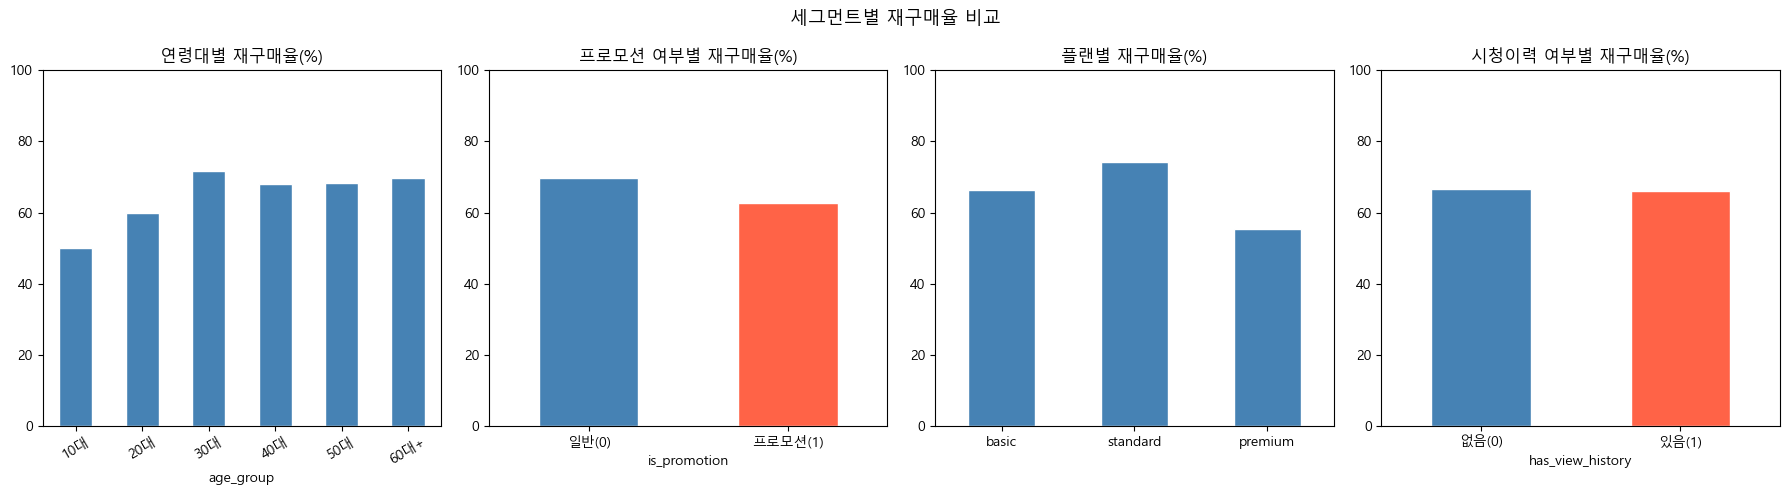

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# 연령대별 재구매율
df_m.groupby('age_group')['is_repurchase'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('연령대별 재구매율(%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=30)

# 프로모션 여부별 재구매율
df_m.groupby('is_promotion')['is_repurchase'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color=['steelblue','tomato'], edgecolor='white')
axes[1].set_title('프로모션 여부별 재구매율(%)')
axes[1].set_xticklabels(['일반(0)', '프로모션(1)'], rotation=0)
axes[1].set_ylim(0, 100)

# 플랜별 재구매율
plan_col = None
if 'is_basic' in df_m.columns:
    plan_repurchase = {
        'basic':    df_m[df_m['is_basic']==1]['is_repurchase'].mean()*100,
        'standard': df_m[df_m['is_standard']==1]['is_repurchase'].mean()*100,
        'premium':  df_m[df_m['is_premium']==1]['is_repurchase'].mean()*100,
    }
    pd.Series(plan_repurchase).plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
    axes[2].set_title('플랜별 재구매율(%)')
    axes[2].set_ylim(0, 100)
    axes[2].tick_params(axis='x', rotation=0)

# 시청이력 여부별 재구매율
if 'has_view_history' in df_m.columns:
    df_m.groupby('has_view_history')['is_repurchase'].mean().mul(100).plot(
        kind='bar', ax=axes[3], color=['steelblue','tomato'], edgecolor='white')
    axes[3].set_title('시청이력 여부별 재구매율(%)')
    axes[3].set_xticklabels(['없음(0)', '있음(1)'], rotation=0)
    axes[3].set_ylim(0, 100)

plt.suptitle('세그먼트별 재구매율 비교', fontsize=13)
plt.tight_layout()
plt.show()

## 6-1. 프로모션 여부별 재구매율 비교 (연령대 / 플랜 / 시청이력)

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\253702923.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_data = df_m.groupby(['age_group', 'is_promotion'])['is_repurchase'].mean().mul(100).unstack()


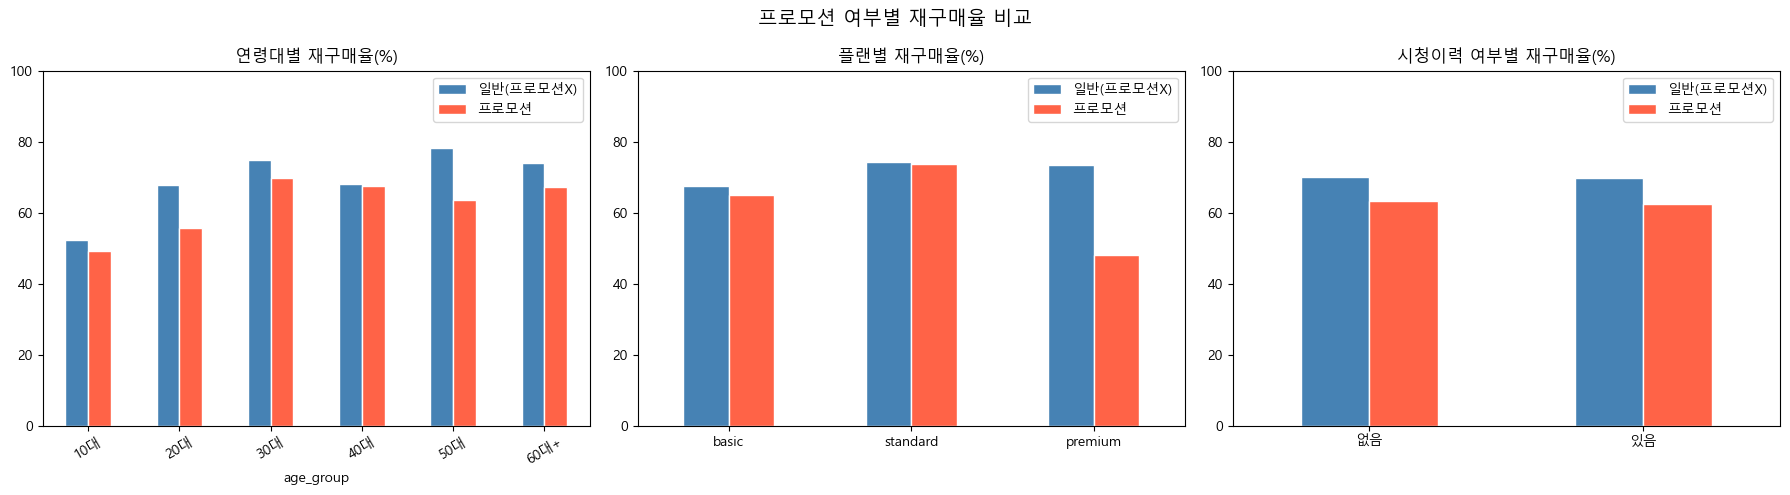

[연령대별 재구매율 (%)]
           일반(프로모션X)  프로모션
age_group                 
10대             52.3  49.4
20대             67.9  55.8
30대             74.8  69.8
40대             68.2  67.5
50대             78.2  63.5
60대+            74.1  67.3

[플랜별 재구매율 (%)]
          일반(프로모션X)  프로모션
basic          67.5  65.0
standard       74.4  73.8
premium        73.4  48.0

[시청이력 여부별 재구매율 (%)]
    일반(프로모션X)  프로모션
없음       70.1  63.2
있음       69.8  62.5


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'tomato']
labels = ['일반(프로모션X)', '프로모션']

# --- 연령대별 ---
age_data = df_m.groupby(['age_group', 'is_promotion'])['is_repurchase'].mean().mul(100).unstack()
age_data.columns = labels
age_data.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('연령대별 재구매율(%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# --- 플랜별 ---
plan_data = {}
for promo_val, label in enumerate(labels):
    sub = df_m[df_m['is_promotion'] == promo_val]
    plan_data[label] = {
        'basic':    sub[sub['is_basic']==1]['is_repurchase'].mean() * 100,
        'standard': sub[sub['is_standard']==1]['is_repurchase'].mean() * 100,
        'premium':  sub[sub['is_premium']==1]['is_repurchase'].mean() * 100,
    }
plan_df = pd.DataFrame(plan_data)
plan_df.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('플랜별 재구매율(%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

# --- 시청이력 여부별 ---
view_data = df_m.groupby(['has_view_history', 'is_promotion'])['is_repurchase'].mean().mul(100).unstack()
view_data.columns = labels
view_data.index = ['없음', '있음']
view_data.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('시청이력 여부별 재구매율(%)')
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()

plt.suptitle('프로모션 여부별 재구매율 비교', fontsize=14)
plt.tight_layout()
plt.show()

# --- 수치 출력 ---
print('=' * 50)
print('[연령대별 재구매율 (%)]')
print(age_data.round(1).to_string())

print()
print('=' * 50)
print('[플랜별 재구매율 (%)]')
print(plan_df.round(1).to_string())

print()
print('=' * 50)
print('[시청이력 여부별 재구매율 (%)]')
print(view_data.round(1).to_string())

## 6-2. 프로모션X vs 반값 비교

In [57]:
# 가격 분포 먼저 확인
print('[전체 price 분포]')
print(df_m['price'].value_counts().sort_index())
print()
print('[product_code별 price 분포]')
print(df_m.groupby(['product_code', 'price']).size().reset_index(name='count').to_string(index=False))

[전체 price 분포]
price
9.89           6
9.99        2104
10.99         37
13.19          2
13.49        609
14.29         18
16.49        213
17.59          2
20.49          1
21.99          1
24.19          1
27.49          1
29.69          1
100.00      9061
3350.00        1
3950.00      129
4900.00        1
5450.00       41
5900.00        5
6210.00        4
6700.00       76
6900.00       23
6950.00       50
7900.00     3299
10900.00    1570
11550.00       1
11800.00       2
13750.00      30
13900.00     587
Name: count, dtype: int64

[product_code별 price 분포]
product_code    price  count
     pk_1070  7900.00      3
     pk_1136    10.99     31
     pk_1139    14.29      7
     pk_1145    13.19      1
     pk_1148    17.59      1
     pk_1154    17.59      1
     pk_1157    24.19      1
     pk_1158    29.69      1
     pk_1166    27.49      1
      pk_121  6210.00      4
      pk_121  6900.00     22
      pk_122  7900.00      4
      pk_123 10900.00      7
      pk_129  6900.00      1


## 6-2. 가격 유형별 재구매율 비교 (정가 / 반값 / 100원딜)

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\276401716.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  label: df_m[df_m['prom'] == val].groupby('age_group')['is_repurchase'].mean().mul(100)
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\276401716.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'basic':    df_m[df_m['prom'] == val][df_m['is_basic']==1]['is_repurchase'].mean() * 100,
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\276401716.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  'standard': df_m[df_m['prom'] == val][df_m['is_standard']==1]['is_repurchase'].mean() * 100,
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\276401716.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame 

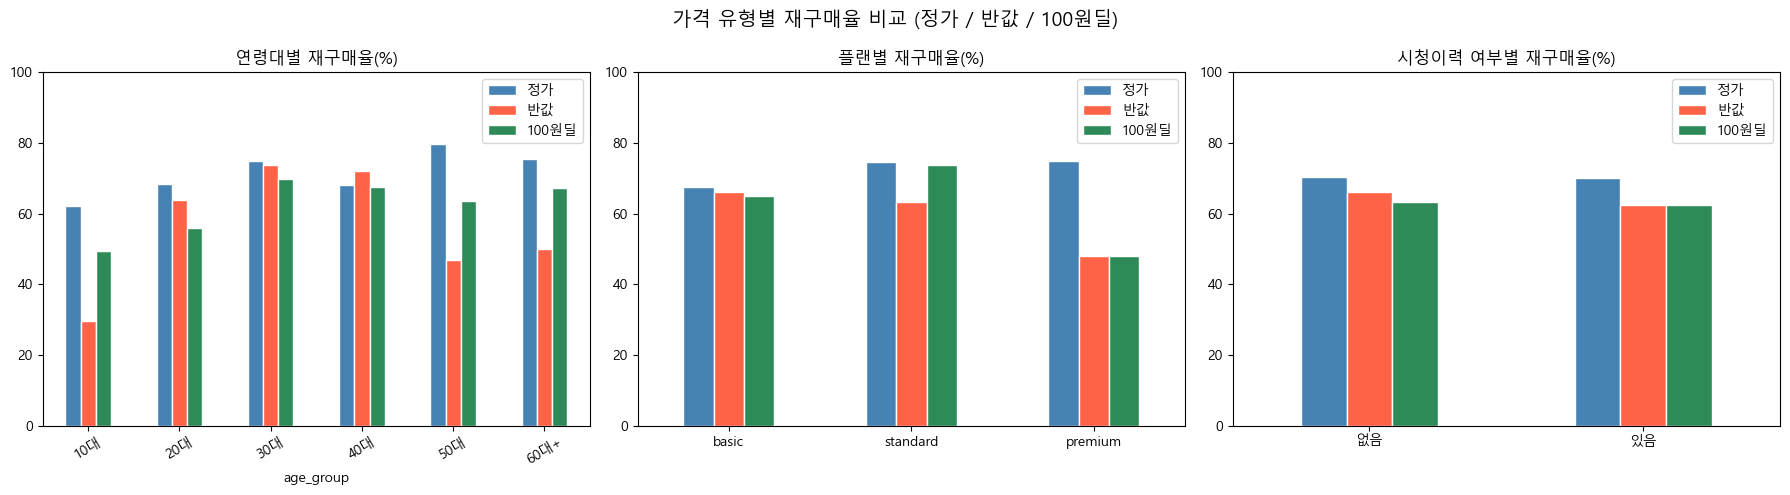

[연령대별 재구매율 (%)]
             정가    반값  100원딜
age_group                   
10대        62.3  29.6   49.4
20대        68.3  63.8   55.8
30대        74.8  73.8   69.8
40대        68.2  72.0   67.5
50대        79.8  47.1   63.5
60대+       75.5  50.0   67.3

[플랜별 재구매율 (%)]
            정가    반값  100원딜
basic     67.6  66.1   65.0
standard  74.6  63.4   73.8
premium   75.0  48.0   48.0

[시청이력 여부별 재구매율 (%)]
      정가    반값  100원딜
없음  70.3  66.1   63.2
있음  70.1  62.4   62.5


In [58]:
prom_labels = {0: '정가', 1: '반값', 2: '100원딜'}
colors = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 연령대별
age_df = pd.DataFrame({
    label: df_m[df_m['prom'] == val].groupby('age_group')['is_repurchase'].mean().mul(100)
    for val, label in prom_labels.items()
})
age_df.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('연령대별 재구매율(%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# 플랜별
plan_df2 = pd.DataFrame({
    label: {
        'basic':    df_m[df_m['prom'] == val][df_m['is_basic']==1]['is_repurchase'].mean() * 100,
        'standard': df_m[df_m['prom'] == val][df_m['is_standard']==1]['is_repurchase'].mean() * 100,
        'premium':  df_m[df_m['prom'] == val][df_m['is_premium']==1]['is_repurchase'].mean() * 100,
    }
    for val, label in prom_labels.items()
})
plan_df2.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('플랜별 재구매율(%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

# 시청이력 여부별
view_df = pd.DataFrame({
    label: df_m[df_m['prom'] == val].groupby('has_view_history')['is_repurchase'].mean().mul(100)
    for val, label in prom_labels.items()
})
view_df.index = ['없음', '있음']
view_df.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('시청이력 여부별 재구매율(%)')
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()

plt.suptitle('가격 유형별 재구매율 비교 (정가 / 반값 / 100원딜)', fontsize=14)
plt.tight_layout()
plt.show()

# 수치 출력
print('=' * 50)
print('[연령대별 재구매율 (%)]')
print(age_df.round(1).to_string())
print()
print('=' * 50)
print('[플랜별 재구매율 (%)]')
print(plan_df2.round(1).to_string())
print()
print('=' * 50)
print('[시청이력 여부별 재구매율 (%)]')
print(view_df.round(1).to_string())

## 6-4. 변수 간 교호작용 전체 탐색 (재구매율 히트맵)

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = (df_m.groupby([v1, v2])['is_repurchase']
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = (df_m.groupby([v1, v2])['is_repurchase']
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence 

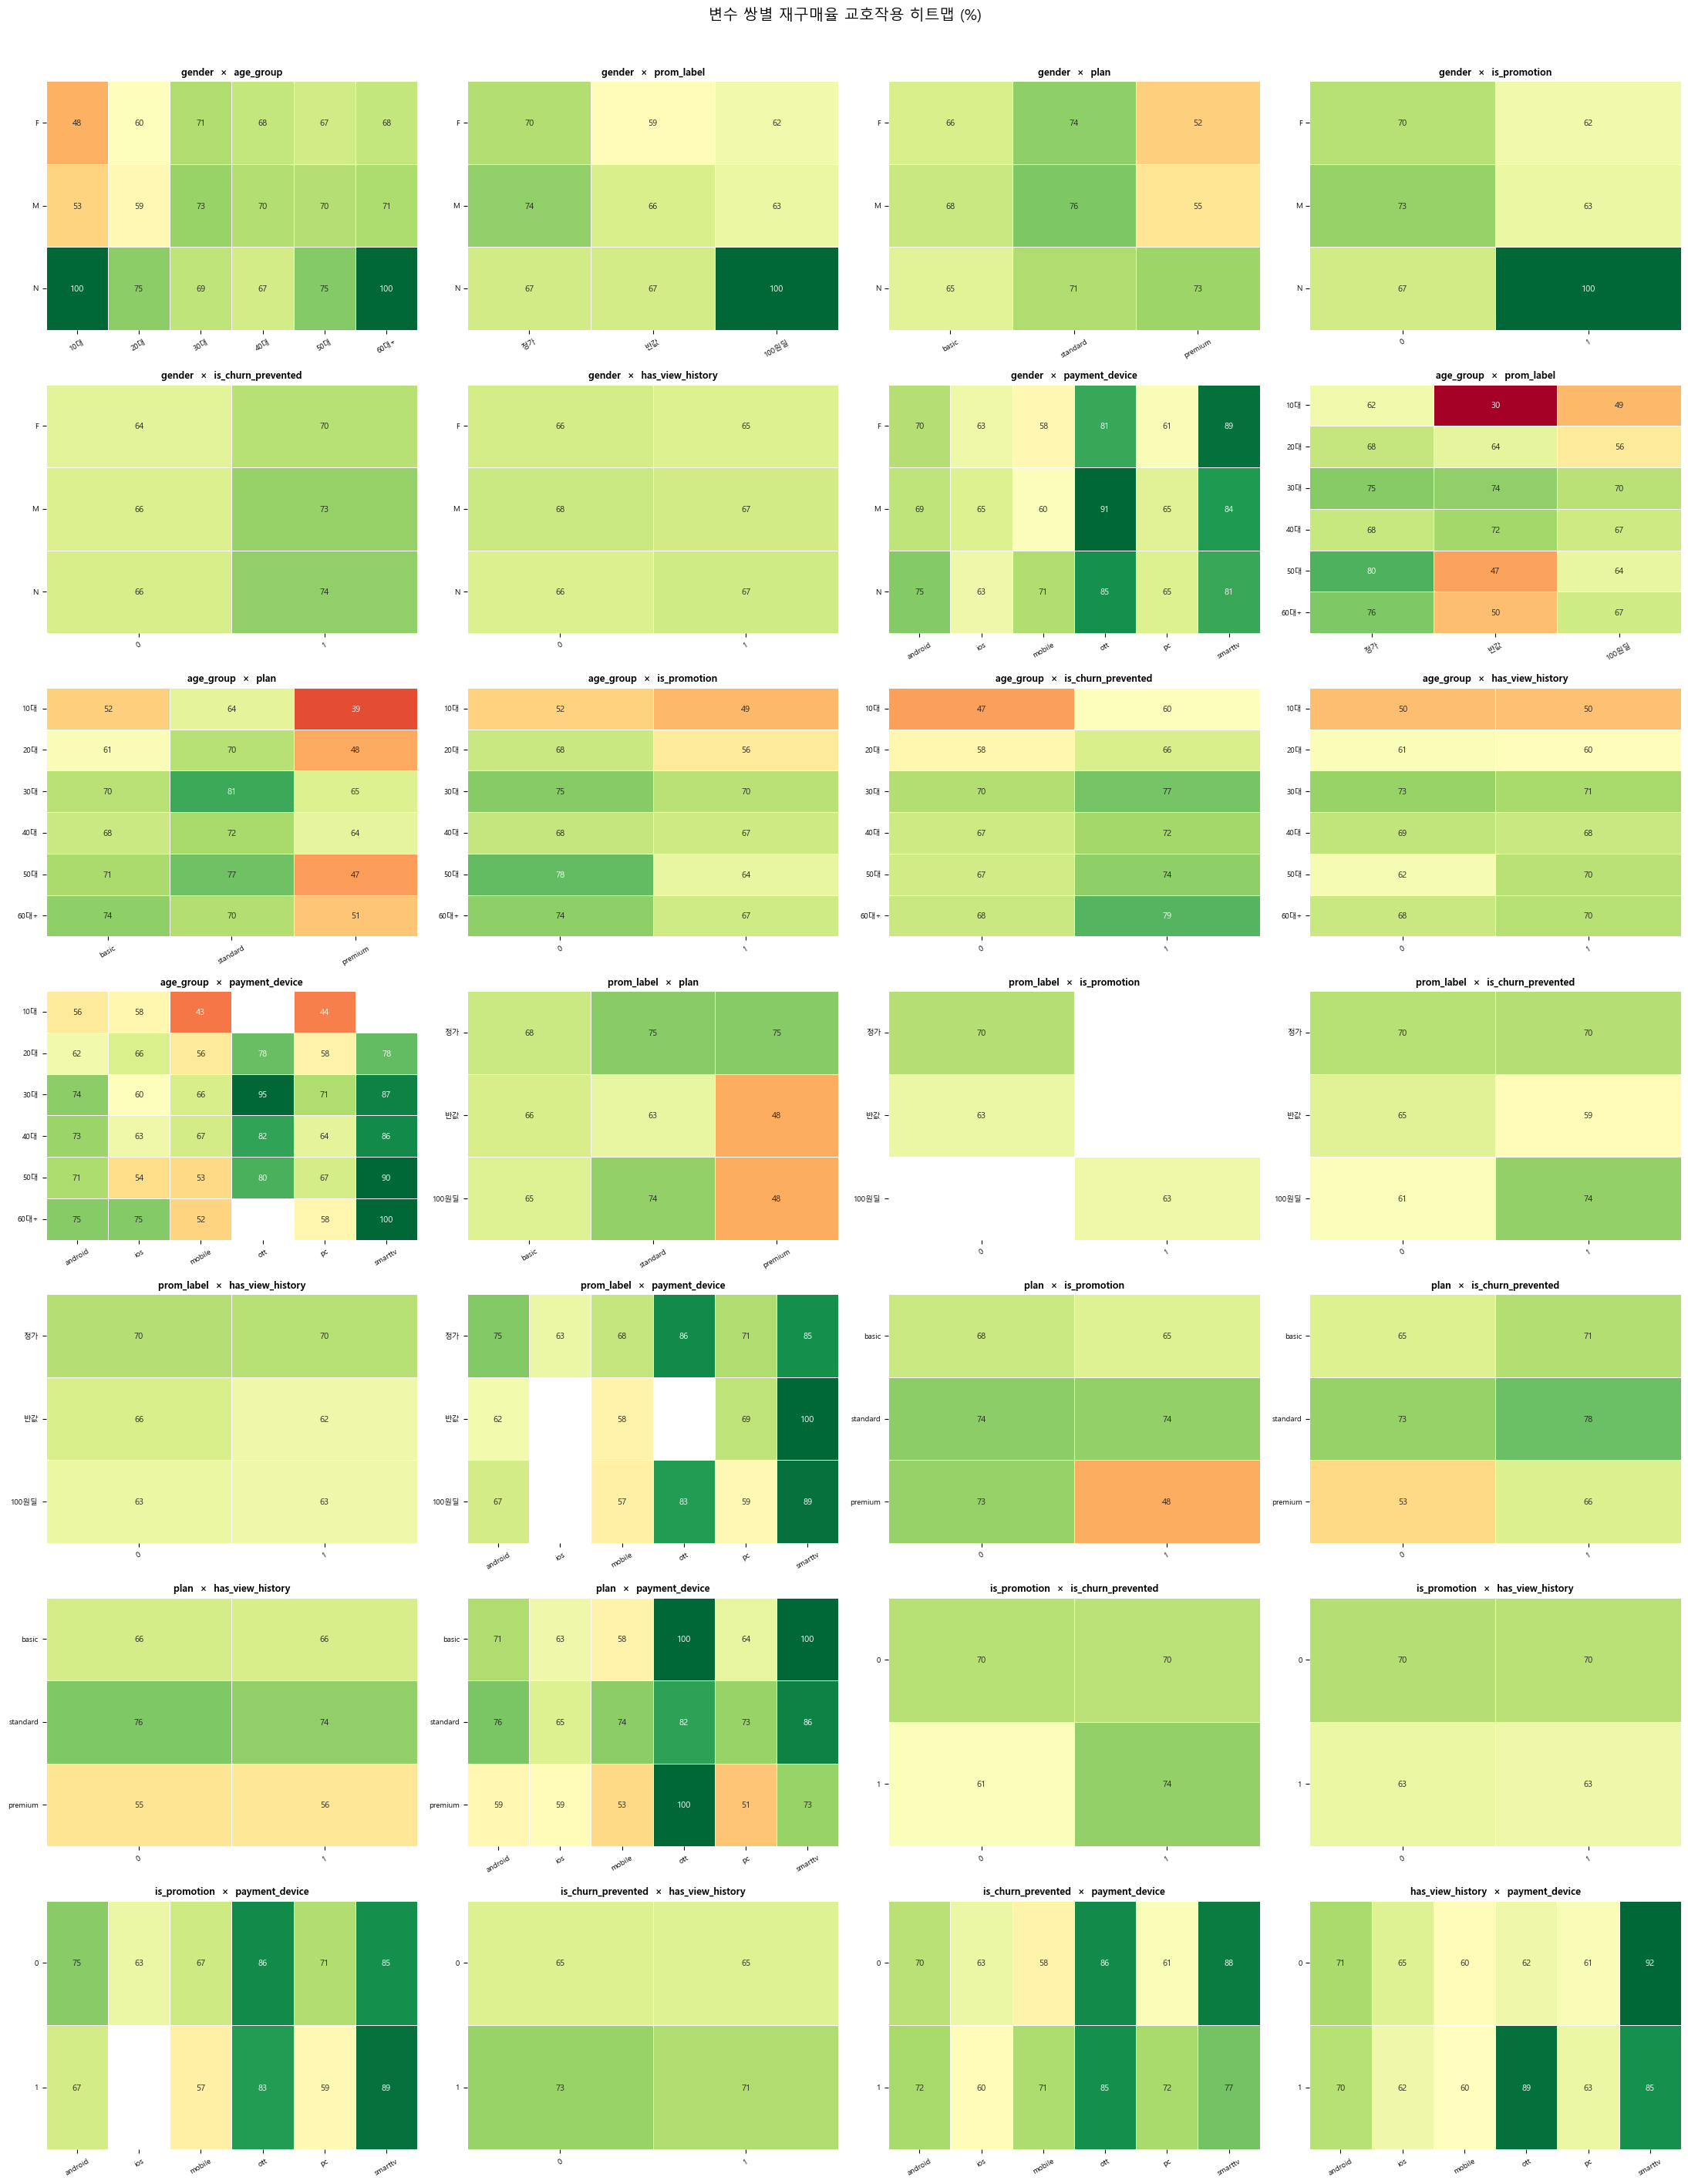

교호작용 변동성 순위 (재구매율 최대-최소 범위):
                                    변수쌍  최소(%)  최대(%)  범위(%)  표준편차
           age_group  ×  payment_device   43.1  100.0   56.9  13.9
                   gender  ×  age_group   48.3  100.0   51.7  13.0
               age_group  ×  prom_label   29.6   79.8   50.2  12.6
                plan  ×  payment_device   50.7  100.0   49.3  15.8
          prom_label  ×  payment_device   57.1  100.0   42.9  13.1
                     age_group  ×  plan   38.8   81.3   42.5  11.7
                  gender  ×  prom_label   59.5  100.0   40.5  12.1
                gender  ×  is_promotion   62.3  100.0   37.7  14.0
       age_group  ×  is_churn_prevented   46.7   79.4   32.7   8.9
              gender  ×  payment_device   58.4   90.9   32.5  10.6
    has_view_history  ×  payment_device   59.5   91.7   32.1  11.8
        is_promotion  ×  payment_device   57.1   88.7   31.6  11.4
  is_churn_prevented  ×  payment_device   57.8   87.6   29.8  10.4
             age_group  ×  is_pro

C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df_m.groupby([v1, v2])['is_repurchase'].mean().mul(100)
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df_m.groupby([v1, v2])['is_repurchase'].mean().mul(100)
C:\Users\82109\AppData\Local\Temp\ipykernel_25840\2666440915.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

In [60]:
import seaborn as sns
import numpy as np

# plan 단일 컬럼 생성
df_m['plan'] = np.where(df_m['is_basic'], 'basic',
               np.where(df_m['is_standard'], 'standard', 'premium'))

# prom 레이블
df_m['prom_label'] = df_m['prom'].map({0: '정가', 1: '반값', 2: '100원딜'})

# 교호작용 분석 변수
vars_info = [
    ('gender',            None),
    ('age_group',         None),
    ('prom_label',        ['정가', '반값', '100원딜']),
    ('plan',              ['basic', 'standard', 'premium']),
    ('is_promotion',      None),
    ('is_churn_prevented',None),
    ('has_view_history',  None),
    ('payment_device',    None),
]
var_names = [v for v, _ in vars_info]
var_order  = {v: o for v, o in vars_info}

pairs = [(var_names[i], var_names[j])
         for i in range(len(var_names))
         for j in range(i+1, len(var_names))]

n_cols = 4
n_rows = (len(pairs) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for idx, (v1, v2) in enumerate(pairs):
    pivot = (df_m.groupby([v1, v2])['is_repurchase']
               .mean().mul(100).unstack())

    if var_order[v1]:
        pivot = pivot.reindex(var_order[v1])
    if var_order[v2]:
        pivot = pivot.reindex(columns=var_order[v2])

    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                vmin=30, vmax=90, ax=axes[idx], cbar=False,
                linewidths=0.5, annot_kws={'size': 8})
    axes[idx].set_title(f'{v1}  ×  {v2}', fontsize=9, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=30, labelsize=7)
    axes[idx].tick_params(axis='y', rotation=0, labelsize=7)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

for ax in axes[len(pairs):]:
    ax.set_visible(False)

plt.suptitle('변수 쌍별 재구매율 교호작용 히트맵 (%)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 변동성 순위 (range 기준)
print('교호작용 변동성 순위 (재구매율 최대-최소 범위):')
rows = []
for v1, v2 in pairs:
    rates = df_m.groupby([v1, v2])['is_repurchase'].mean().mul(100)
    rows.append({
        '변수쌍': f'{v1}  ×  {v2}',
        '최소(%)': round(rates.min(), 1),
        '최대(%)': round(rates.max(), 1),
        '범위(%)': round(rates.max() - rates.min(), 1),
        '표준편차': round(rates.std(), 1),
    })
rank_df = pd.DataFrame(rows).sort_values('범위(%)', ascending=False)
print(rank_df.to_string(index=False))

## 6-5. 주요 교호작용 상세 분석

In [ ]:
import seaborn as sns
import numpy as np

# 필요 컬럼 생성 (없을 경우 대비)
if 'age_group' not in df_m.columns:
    df_m['age_group'] = pd.cut(df_m['age'], bins=[0,19,29,39,49,59,100],
                               labels=['10대','20대','30대','40대','50대','60대+'])
if 'plan' not in df_m.columns:
    df_m['plan'] = np.where(df_m['is_basic'], 'basic',
                   np.where(df_m['is_standard'], 'standard', 'premium'))
if 'prom_label' not in df_m.columns:
    df_m['prom_label'] = df_m['prom'].map({0: '정가', 1: '반값', 2: '100원딜'})

top_pairs = [
    ('age_group',  'prom_label',         ['10대','20대','30대','40대','50대','60대+'], ['정가','반값','100원딜']),
    ('age_group',  'plan',               ['10대','20대','30대','40대','50대','60대+'], ['basic','standard','premium']),
    ('age_group',  'is_churn_prevented', ['10대','20대','30대','40대','50대','60대+'], [0, 1]),
    ('age_group',  'is_promotion',       ['10대','20대','30대','40대','50대','60대+'], [0, 1]),
    ('prom_label', 'plan',               ['정가','반값','100원딜'],                    ['basic','standard','premium']),
]

fig, axes = plt.subplots(5, 3, figsize=(20, 24))

for row, (v1, v2, order1, order2) in enumerate(top_pairs):
    rate = df_m.groupby([v1, v2], observed=True)['is_repurchase'].mean().mul(100).unstack()
    cnt  = df_m.groupby([v1, v2], observed=True).size().unstack()
    if order1: rate = rate.reindex(order1);         cnt = cnt.reindex(order1)
    if order2: rate = rate.reindex(columns=order2); cnt = cnt.reindex(columns=order2)

    # 재구매율 히트맵
    sns.heatmap(rate, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=30, vmax=90, ax=axes[row][0], cbar=False, linewidths=0.5)
    axes[row][0].set_title(f'[재구매율%]  {v1} × {v2}', fontsize=10, fontweight='bold')
    axes[row][0].tick_params(axis='x', rotation=30, labelsize=8)
    axes[row][0].tick_params(axis='y', rotation=0,  labelsize=8)
    axes[row][0].set_xlabel(''); axes[row][0].set_ylabel('')

    # 샘플 수 히트맵
    sns.heatmap(cnt, annot=True, fmt='d', cmap='Blues',
                ax=axes[row][1], cbar=False, linewidths=0.5)
    axes[row][1].set_title(f'[샘플수]  {v1} × {v2}', fontsize=10)
    axes[row][1].tick_params(axis='x', rotation=30, labelsize=8)
    axes[row][1].tick_params(axis='y', rotation=0,  labelsize=8)
    axes[row][1].set_xlabel(''); axes[row][1].set_ylabel('')
    small = cnt[cnt < 30].stack()
    if not small.empty:
        axes[row][1].set_xlabel(f'⚠ n<30 셀 존재', fontsize=8, color='red')

    # 추세 꺾은선
    for col in rate.columns:
        axes[row][2].plot(rate.index.astype(str), rate[col], marker='o', label=str(col))
    axes[row][2].set_title(f'[추세]  {v1} × {v2}', fontsize=10)
    axes[row][2].set_ylim(0, 105)
    axes[row][2].set_ylabel('재구매율(%)')
    axes[row][2].tick_params(axis='x', rotation=30, labelsize=8)
    axes[row][2].legend(fontsize=8)
    axes[row][2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('주요 교호작용 상세 분석 (재구매율 / 샘플수 / 추세)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# 수치 출력
for v1, v2, order1, order2 in top_pairs:
    rate = df_m.groupby([v1, v2], observed=True)['is_repurchase'].mean().mul(100).unstack()
    cnt  = df_m.groupby([v1, v2], observed=True).size().unstack()
    if order1: rate = rate.reindex(order1);         cnt = cnt.reindex(order1)
    if order2: rate = rate.reindex(columns=order2); cnt = cnt.reindex(columns=order2)
    print('=' * 55)
    print(f'[{v1} × {v2}]  재구매율(%)')
    print(rate.round(1).to_string())
    print(f'\n샘플 수')
    print(cnt.to_string())
    print()